Generates the plots and tables for paper "RDMDL ..."

In [9]:
import numpy as np
from itertools import product
from scipy.stats import norm
from numpy.polynomial.legendre import leggauss

from bicausal.metrics.evaluators import evaluate_lisbon, evaluate_tuebingen, evaluate_synthetic, construct_table
from bicausal.metrics.drawers import plot_dataset_curves_vs, plot_method_curves
from bicausal.helpers.processers import process_lisbon_scores
from bicausal.helpers.runners import run_lisbon, run_tuebingen

all_methods=['ANM',"bQCD","CAM","CDCI","CDS","CGNN","FOM","HECI","IGCI","LCube","LOCI","NNCL","RECI","ROCHE","Slope","Sloppy","RDMDL"]
all_methods_excluded=['ANM',"bQCD","CAM","CDCI","CDS","CGNN","FOM","HECI","IGCI","LCube","LOCI","NNCL","RECI","ROCHE","Slope","Sloppy"]

In [ ]:
#Table 1: performance of $L(X)$ predictors of COMIC, LCube, and Slope
def squared_noise(x):
    x = (x - np.mean(x)) / np.std(x)  # normalize var(x)=1
    return np.sum((x - np.mean(x))**2)


def comic_lx(d, scaling="normalize"):
    x, y = d
    x = np.array(x).flatten()
    y = np.array(y).flatten()

    if scaling == "normalize":
        x = (x - np.mean(x)) / np.std(x)
        y = (y - np.mean(y)) / np.std(y)

    return squared_noise(y) - squared_noise(x)

def resolution(x):
    x = np.sort(np.asarray(x))
    diffs = np.diff(x)
    res = np.min(diffs[diffs > 0]) if np.any(diffs > 0) else 0
    if res <= 0:
        return np.inf
    return -len(x) * np.log(res)
    
def slope_lx(d, scaling="normalize"):
    x, y = d
    x = np.array(x).flatten()
    y = np.array(y).flatten()

    if scaling == "normalize":
        x = (x - np.mean(x)) / np.std(x)
        y = (y - np.mean(y)) / np.std(y)

    return resolution(y) - resolution(x)



def quantile_scoring(x, q, alpha):
    """
    Equivalent to R's quantileScoring function.
    Computes quantile score for a given quantile level alpha.
    """
    return (alpha - (x < q)) * (x - q)

def gauss_quad_prob(m):
    """
    Equivalent to R's gauss.quad.prob(m)
    Returns nodes and weights for Gaussian quadrature on [0, 1].
    """
    nodes, weights = leggauss(m)
    # Transform from [-1, 1] to [0, 1]
    nodes = 0.5 * (nodes + 1)
    weights = 0.5 * weights
    return {"nodes": nodes, "weights": weights}

def quantile_lx(d, m=10):
    np.random.seed(0)  # Reproducible jitter for discrete data
    x,y=d
    pair=np.column_stack((x, y))
    n = pair.shape[0]

    # Rank transformation (pseudo-observations)
    ranks = np.array([np.argsort(np.argsort(col)) + 1 for col in pair.T]).T
    u = (ranks + np.random.uniform(size=ranks.shape)) / (n + 1)

    # Scale marginals to standard normal
    pair_scaled = norm.ppf(u)

    # Integration weights and nodes
    if n < 200:
        uw = gauss_quad_prob(1)
    else:
        uw = gauss_quad_prob(m)

    cls_list = []
    for uu in uw["nodes"]:
        marg_q = [np.quantile(pair_scaled[:, i], uu) for i in range(2)]
        cl_marginal = [np.mean(quantile_scoring(pair_scaled[:, i], marg_q[i], uu)) for i in range(2)]
        cls_list.append(cl_marginal)

    cls = np.array(cls_list)
    sel = ~np.any(np.isnan(cls), axis=1)
    weights = uw["weights"][sel]
    weights = weights / np.sum(weights)

    cls_weighted = np.sum(cls[sel, :] * weights[:, None], axis=0)

    dx_to_y = cls_weighted[0] 
    dy_to_x = cls_weighted[1] 

    return dy_to_x-dx_to_y

run_lisbon(quantile_lx)
run_lisbon(comic_lx)
run_lisbon(slope_lx)

run_tuebingen(quantile_lx)
run_tuebingen(comic_lx)
run_tuebingen(slope_lx)

🔍 Processing source: canada_greenhouse_gases_2005_2006 (1 files)
⏩ Skipping Energy_use__GJ__Emissions__kt_.txt for quantile_lx (already computed with same parameters)
🔍 Processing source: city_weather_germany (5 files)
⏩ Skipping altitude_precipitation__yearly_value_averaged_over_1961-1990_.txt for quantile_lx (already computed with same parameters)
⏩ Skipping altitude_temperature__average_over_1961-1990_.txt for quantile_lx (already computed with same parameters)
⏩ Skipping latitude_temperature__averaged_over_1961-1990_.txt for quantile_lx (already computed with same parameters)
⏩ Skipping longitude_precipitation__yearly_value_averaged_over_1961-1990_.txt for quantile_lx (already computed with same parameters)
⏩ Skipping longitude_temperature__averaged_over_1961-1990_.txt for quantile_lx (already computed with same parameters)
🔍 Processing source: corn_farming (1 files)
⏩ Skipping Acreage_Yield.txt for quantile_lx (already computed with same parameters)
🔍 Processing source: lettuce_gr

""


In [14]:
evaluate_lisbon(methods=["quantile_lx","comic_lx","slope_lx"],metrics=["LxCIM","accuracy","AUROC","AUDRC"])
evaluate_tuebingen(methods=["quantile_lx","comic_lx","slope_lx"],metrics=["LxCIM","accuracy","AUROC","AUDRC"])
construct_table(methods=["quantile_lx","comic_lx","slope_lx"], datasets=["Lisbon","Tuebingen"], metrics=["LxCIM"], include_variations=False,table_title="RDMDL paper - Table 1 - L(X) predictors performance on Lisbon and Tübingen datasets")

✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv

RESULT TABLE
| Method      | Dataset   |   LxCIM (%) |
|-------------|-----------|-------------|
| comic_lx    | Lisbon    |        56.5 |
| comic_lx    | Tübingen  |        51.4 |
| quantile_lx | Lisbon    |        45.7 |
| quantile_lx | Tübingen  |        53.5 |
| slope_lx    | Lisbon    |        56.2 |
| slope_lx    | Tübingen  |        57.8 |

Table saved to: table\RDMDL paper - Table 1 - L(X) predictors performance on Lisbon and Tübingen datasets.tex


,Method,Dataset,LxCIM (%)
0,comic_lx,Lisbon,56.5
1,comic_lx,Tübingen,51.4
2,quantile_lx,Lisbon,45.7
3,quantile_lx,Tübingen,53.5
4,slope_lx,Lisbon,56.2
5,slope_lx,Tübingen,57.8


In [4]:
evaluate_tuebingen(metrics=["LxCIM","accuracy","AUROC","AUDRC"])
construct_table(datasets=["Tuebingen"], metrics=["LxCIM","accuracy","AUROC","AUDRC"], include_variations=True, table_title="RDMDL Table 1")

✅ Evaluation complete. Results written to results/results.csv

RESULT TABLE
| Method   | Parameters                                       | Dataset   |   LxCIM (%) |   Accuracy (%) |   AUROC (%) |   AUDRC (%) |
|----------|--------------------------------------------------|-----------|-------------|----------------|-------------|-------------|
| ANM      |                                                  | Tübingen  |        61.7 |           60.4 |        61.9 |        62.9 |
| bQCD     |                                                  | Tübingen  |        71.1 |           69.6 |        71.1 |        70.1 |
| CAM      |                                                  | Tübingen  |        45.7 |           52.3 |        46.6 |        43.1 |
| CDCI     |                                                  | Tübingen  |        59.4 |           61.5 |        60.7 |        55   |
| CDS      |                                                  | Tübingen  |        60.2 |           60.5 |        

,Method,Parameters,Dataset,LxCIM (%),Accuracy (%),AUROC (%),AUDRC (%)
0,ANM,,Tübingen,61.7,60.4,61.9,62.9
15,bQCD,,Tübingen,71.1,69.6,71.1,70.1
1,CAM,,Tübingen,45.7,52.3,46.6,43.1
2,CDCI,,Tübingen,59.4,61.5,60.7,55.0
3,CDS,,Tübingen,60.2,60.5,59.0,57.8
4,CGNN,"{""nruns"": 3,""test_epochs"": 2,""train_epochs"": 10}",Tübingen,62.8,61.5,61.6,69.6
5,FOM,,Tübingen,46.1,45.5,45.1,40.9
6,HECI,,Tübingen,74.1,70.5,75.3,79.2
7,IGCI,,Tübingen,70.0,60.9,69.8,73.3
8,LCube,,Tübingen,62.4,58.9,58.0,70.1


In [7]:
evaluate_lisbon(metrics=["LxCIM","accuracy","AUROC","AUDRC"])
construct_table(datasets=["Lisbon"], metrics=["LxCIM","accuracy","AUROC","AUDRC"], include_variations=True, table_title="RDMDL Table 2")

✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv

RESULT TABLE
| Method   | Parameters                                       | Dataset   |   LxCIM (%) |   Accuracy (%) |   AUROC (%) |   AUDRC (%) |
|----------|--------------------------------------------------|-----------|-------------|----------------|-------------|-------------|
| ANM      |                                                  | Lisbon    |        56.9 |           57.6 |        56.8 |        58.3 |
| bQCD     |                                                  | Lisbon    |        60.1 |           59.4 |        59.9 |        59.7 |
| CAM      |                                                  | Lisbon    

,Method,Parameters,Dataset,LxCIM (%),Accuracy (%),AUROC (%),AUDRC (%)
0,ANM,,Lisbon,56.9,57.6,56.8,58.3
15,bQCD,,Lisbon,60.1,59.4,59.9,59.7
1,CAM,,Lisbon,47.1,49.7,47.2,44.5
2,CDCI,,Lisbon,62.4,57.5,62.3,65.3
3,CDS,,Lisbon,47.7,50.3,47.7,43.7
4,CGNN,"{""nruns"": 3,""test_epochs"": 2,""train_epochs"": 10}",Lisbon,50.7,51.4,50.7,52.1
5,FOM,,Lisbon,38.9,42.4,38.9,37.2
6,HECI,,Lisbon,56.3,58.3,56.5,54.2
7,IGCI,,Lisbon,66.0,63.2,65.8,64.1
8,LCube,,Lisbon,46.4,40.0,46.3,51.5


(<Figure size 700x600 with 1 Axes>,
 [<Axes: title={'center': 'RDMDL - LxCIM'}, xlabel='Decision Rate', ylabel='Cumulative Accuracy'>])

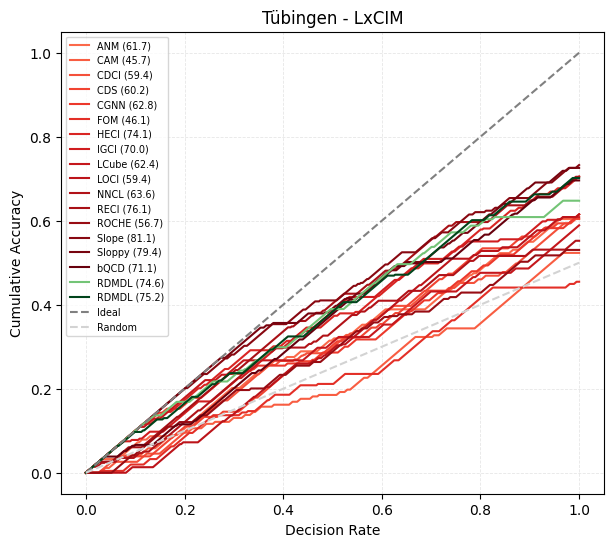

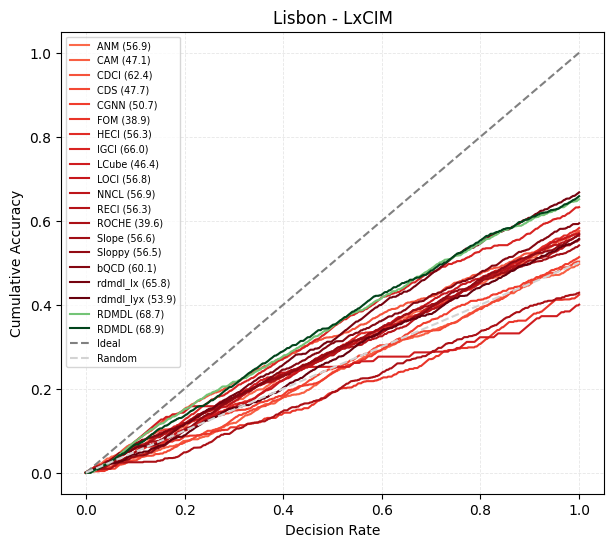

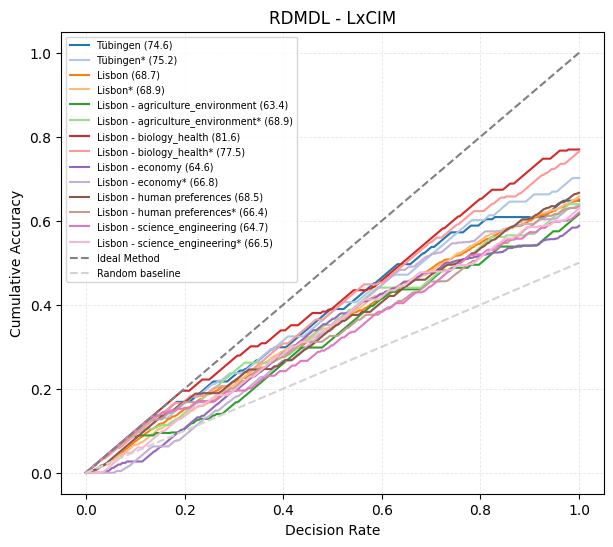

In [2]:
#Figure 1
plot_dataset_curves_vs("Tuebingen",["RDMDL"], include_variations=True, show_params=False,figure_name="RDMDL Figure 1 Tuebingen")
plot_dataset_curves_vs("Lisbon",["RDMDL"], include_variations=True, show_params=False, figure_name="RDMDL Figure 1 Lisbon")
plot_method_curves("RDMDL", datasets=["Tuebingen","Lisbon","Lisbon - agriculture_environment","Lisbon - biology_health","Lisbon - economy","Lisbon - human_predictions","Lisbon - science_engineering"], include_variations=True, figure_name="RDMDL Figure 1 method curves")

In [5]:
evaluate_synthetic("CE",metrics=["LxCIM","accuracy","AUROC","AUDRC"])
evaluate_synthetic("ANLSMN",metrics=["LxCIM","accuracy","AUROC","AUDRC"])
evaluate_synthetic("SIM",metrics=["LxCIM","accuracy","AUROC","AUDRC"])
construct_table(datasets=["CE","ANLSMN","SIM"], include_variations=True, table_title="RDMDL Synthetic Table Appendix")

⚠️ Skipping method=CGNN, params='' on CE-Cha due to missing pairs: [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 

,Method,Parameters,Dataset,LxCIM (%),Accuracy (%)
0,ANM,,AN,47.2,48.8
1,ANM,,AN-s,47.1,44.2
2,ANM,,CE-Cha,34.3,40.0
3,ANM,,CE-Gauss,43.3,45.3
4,ANM,,CE-Multi,48.7,51.0
...,...,...,...,...,...
141,Slope,,LS-s,11.0,17.0
142,Slope,,MN-U,1.1,7.0
143,Slope,,SIM-ln,44.5,47.0
144,Sloppy,,CE-Net,70.1,62.3


In [11]:
construct_table(methods=["RDMDL"],datasets=["CE","ANLSMN","SIM"], include_variations=True, table_title="RDMDL Table 2 Synthetic")


RESULT TABLE
| Method   | Parameters       | Dataset   |   LxCIM (%) |   Accuracy (%) |
|----------|------------------|-----------|-------------|----------------|
| RDMDL    |                  | AN        |        17.2 |           27   |
| RDMDL    |                  | AN-s      |        48.7 |           49   |
| RDMDL    |                  | CE-Cha    |        64.2 |           60.7 |
| RDMDL    |                  | CE-Gauss  |        64.1 |           58.7 |
| RDMDL    |                  | CE-Multi  |        96.6 |           88.7 |
| RDMDL    |                  | CE-Net    |        80.7 |           72   |
| RDMDL    |                  | LS        |        24   |           34   |
| RDMDL    |                  | LS-s      |        92.4 |           87   |
| RDMDL    |                  | MN-U      |        98.6 |           93   |
| RDMDL    |                  | SIM       |        61.2 |           55   |
| RDMDL    |                  | SIM-c     |        66.3 |           64   |
| RDMDL    

,Method,Parameters,Dataset,LxCIM (%),Accuracy (%)
0,RDMDL,,AN,17.2,27.0
1,RDMDL,,AN-s,48.7,49.0
2,RDMDL,,CE-Cha,64.2,60.7
3,RDMDL,,CE-Gauss,64.1,58.7
4,RDMDL,,CE-Multi,96.6,88.7
5,RDMDL,,CE-Net,80.7,72.0
6,RDMDL,,LS,24.0,34.0
7,RDMDL,,LS-s,92.4,87.0
8,RDMDL,,MN-U,98.6,93.0
9,RDMDL,,SIM,61.2,55.0


In [11]:
evaluate_lisbon(methods=all_methods, metrics=["LxCIM","accuracy","AUROC","AUDRC"])
construct_table(methods=all_methods,datasets=["Lisbon","Lisbon - agriculture_environment","Lisbon - biology_health","Lisbon - economy","Lisbon - human_predictions","Lisbon - science_engineering"], metrics=["LxCIM","accuracy"], include_variations=True, table_title="RDMDL Table Appendix Lisbon All Fields")

✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv

RESULT TABLE
| Method   | Parameters                                       | Dataset                          |   LxCIM (%) |   Accuracy (%) |
|----------|--------------------------------------------------|----------------------------------|-------------|----------------|
| ANM      |                                                  | Lisbon                           |        56.9 |           57.6 |
| ANM      |                                                  | Lisbon - agriculture_environment |        53.1 |           54.1 |
| ANM      |                                                  | Lisbon - biology_health       

,Method,Parameters,Dataset,LxCIM (%),Accuracy (%)
0,ANM,,Lisbon,56.9,57.6
1,ANM,,Lisbon - agriculture_environment,53.1,54.1
2,ANM,,Lisbon - biology_health,45.5,52.7
3,ANM,,Lisbon - economy,43.8,44.6
4,ANM,,Lisbon - human_predictions,58.2,58.7
...,...,...,...,...,...
97,Sloppy,,Lisbon - agriculture_environment,45.2,51.0
98,Sloppy,,Lisbon - biology_health,77.8,69.8
99,Sloppy,,Lisbon - economy,48.6,48.0
100,Sloppy,,Lisbon - human_predictions,58.8,58.4


⚠️ Skipping method=CGNN, params='' on CE-Cha due to missing pairs: [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 

(<Figure size 700x600 with 1 Axes>,
 [<Axes: title={'center': 'SIM-ln - LxCIM'}, xlabel='Decision Rate', ylabel='Cumulative Accuracy'>])

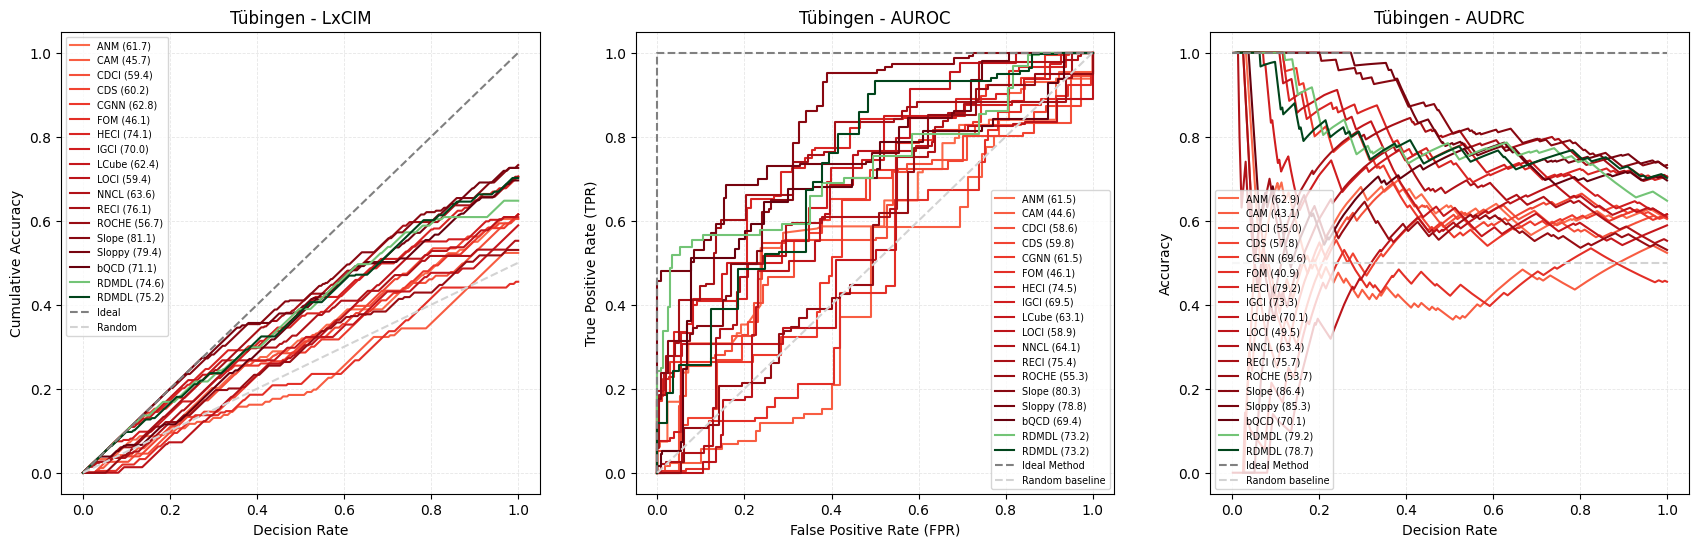

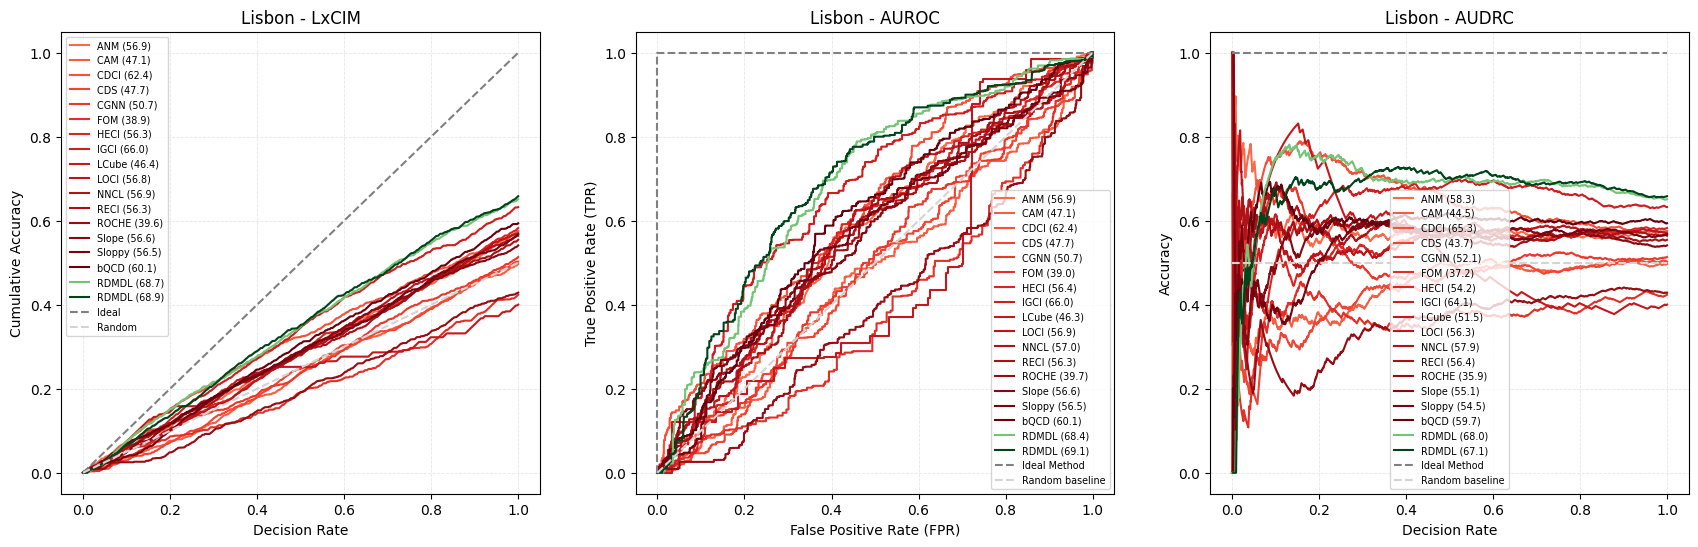

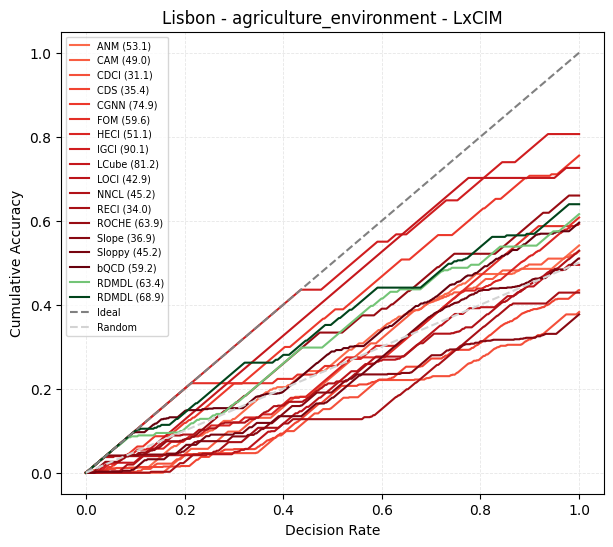

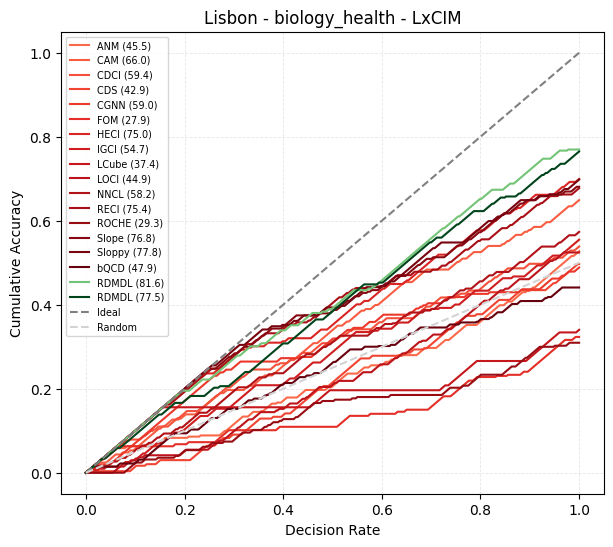

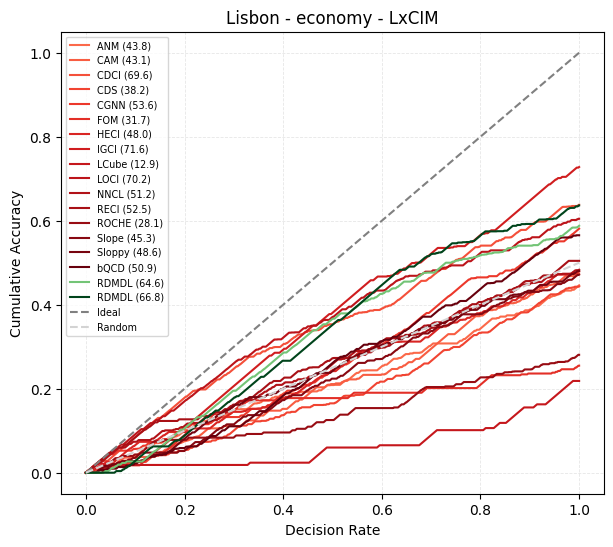

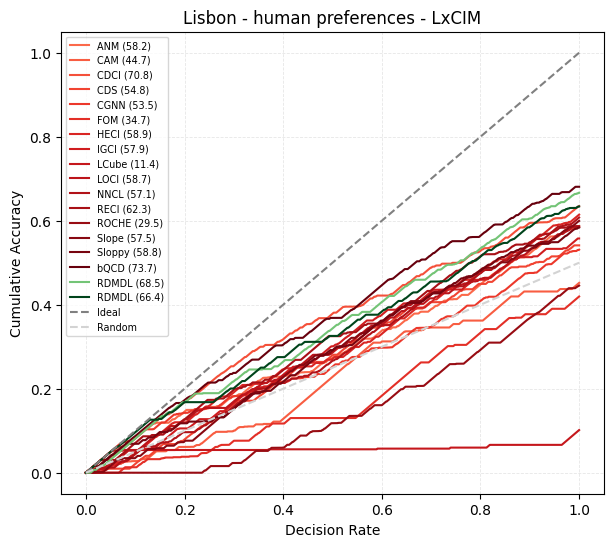

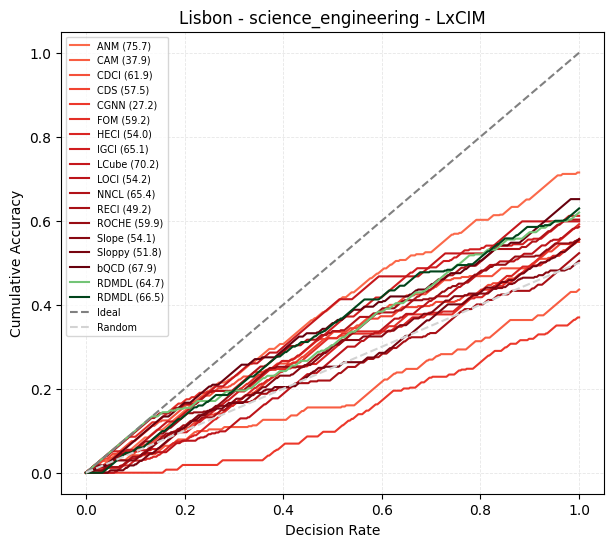

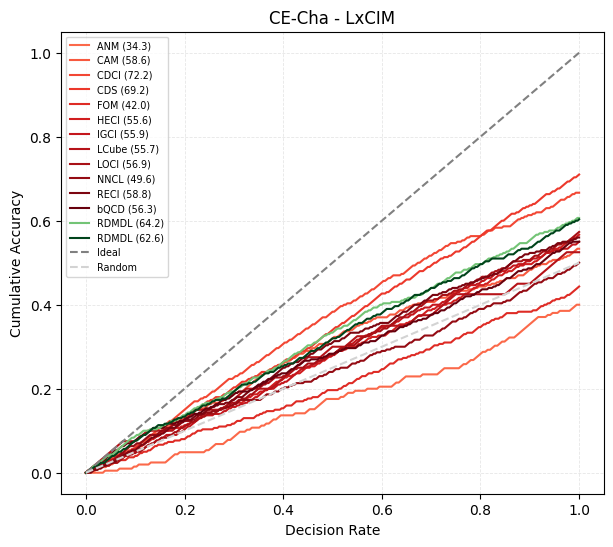

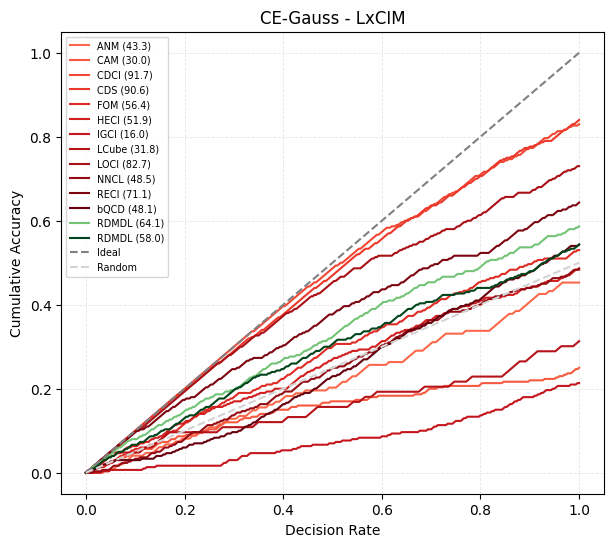

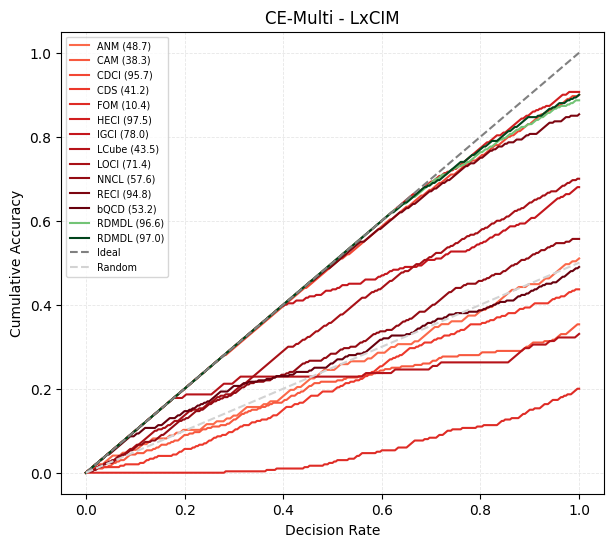

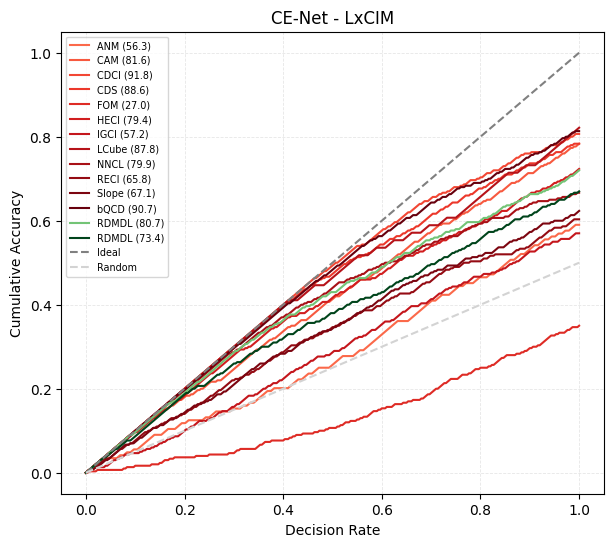

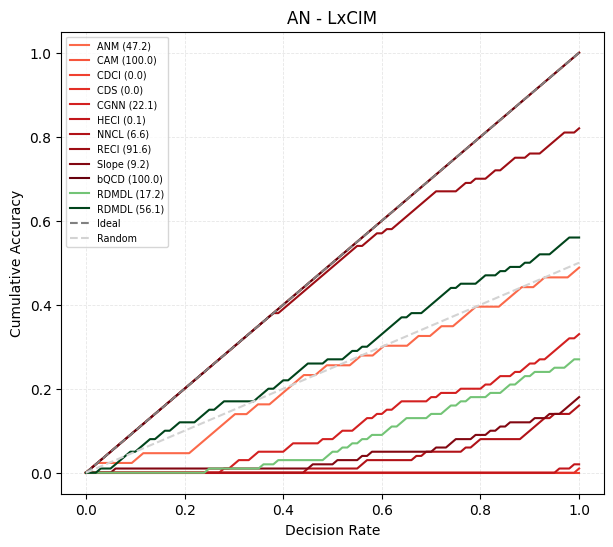

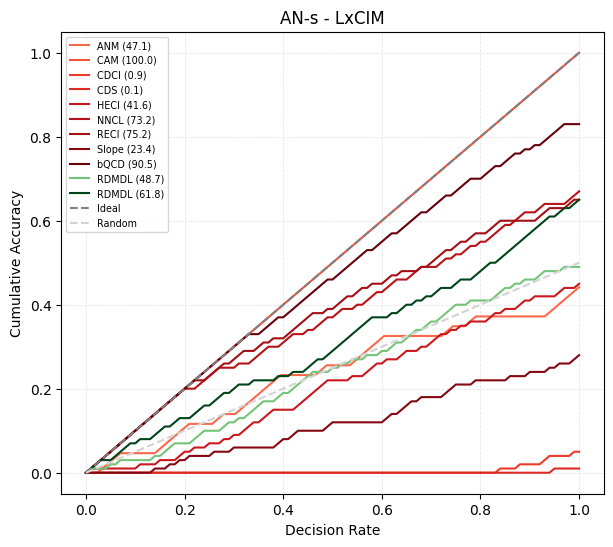

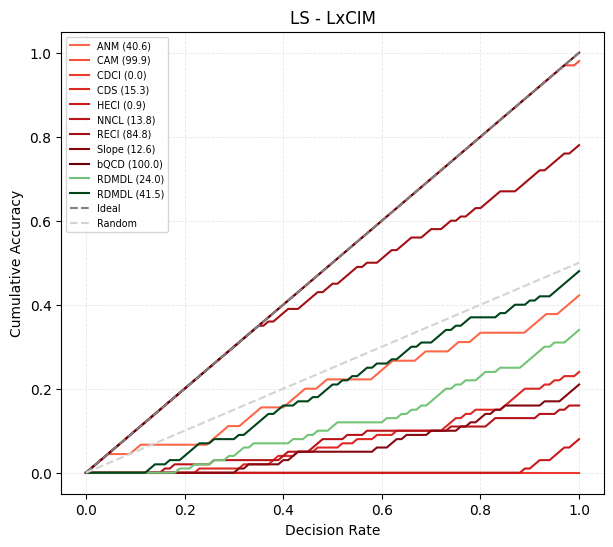

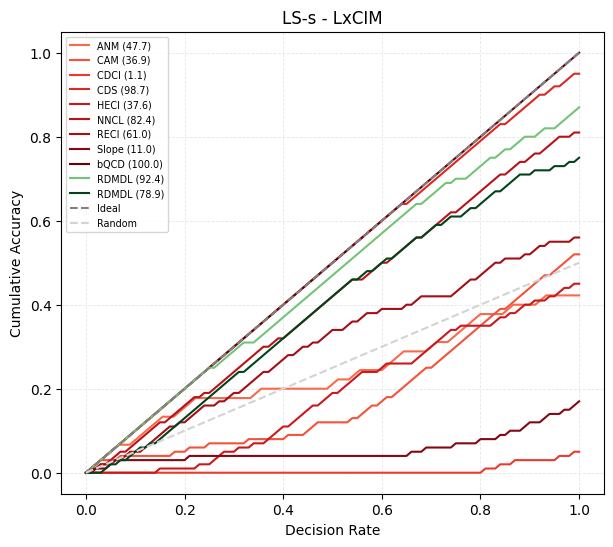

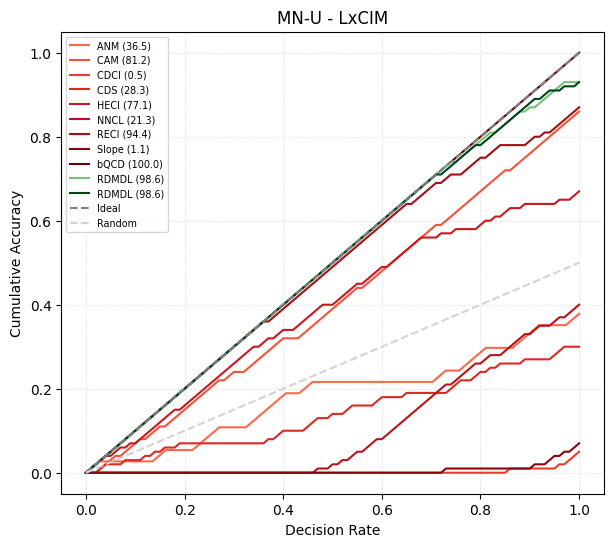

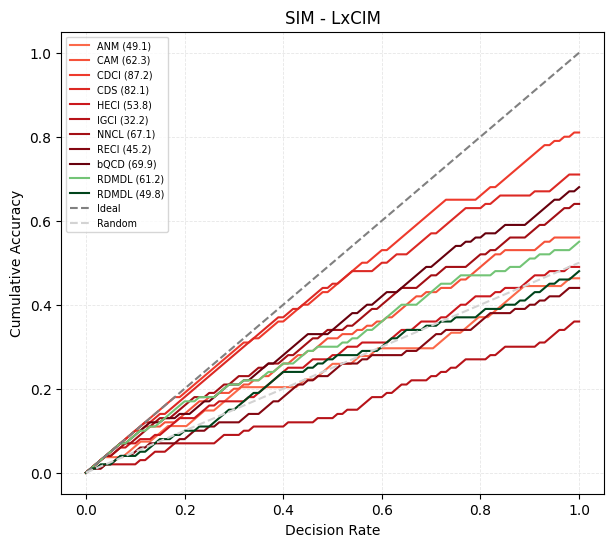

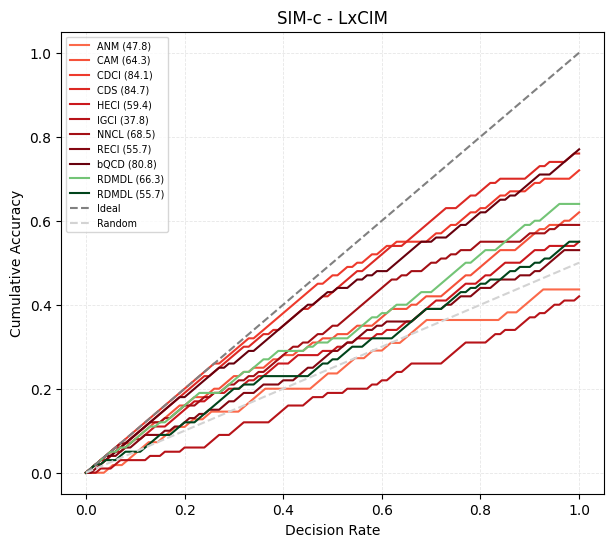

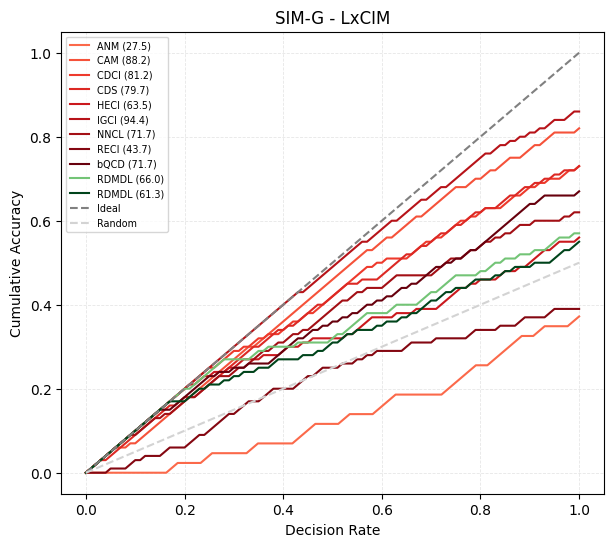

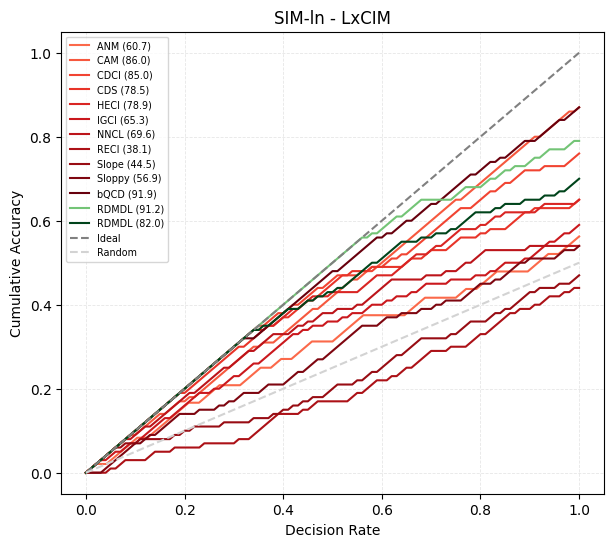

In [3]:
#To the appendix:
#plot for all specific datasets:
plot_dataset_curves_vs("Tuebingen",["RDMDL"],methods_B=all_methods_excluded, metrics=["LxCIM","AUROC","AUDRC"], include_variations=True, show_params=False,figure_name="RDMDL Figure App Tuebingen")
plot_dataset_curves_vs("Lisbon",["RDMDL"],methods_B=all_methods_excluded, metrics=["LxCIM","AUROC","AUDRC"], include_variations=True, show_params=False,figure_name="RDMDL Figure App Lisbon")

#Lisbons
plot_dataset_curves_vs("Lisbon - agriculture_environment",["RDMDL"],methods_B=all_methods_excluded, include_variations=True, show_params=False,figure_name="RDMDL Figure App Lisbon - agriculture_environment")
plot_dataset_curves_vs("Lisbon - biology_health",["RDMDL"],methods_B=all_methods_excluded, include_variations=True, show_params=False,figure_name="RDMDL Figure App Lisbon - biology_health")
plot_dataset_curves_vs("Lisbon - economy",["RDMDL"],methods_B=all_methods_excluded, include_variations=True, show_params=False,figure_name="RDMDL Figure App Lisbon - economy")
plot_dataset_curves_vs("Lisbon - human_predictions",["RDMDL"],methods_B=all_methods_excluded, include_variations=True, show_params=False,figure_name="RDMDL Figure App Lisbon - human_predictions")
plot_dataset_curves_vs("Lisbon - science_engineering",["RDMDL"],methods_B=all_methods_excluded, include_variations=True, show_params=False,figure_name="RDMDL Figure App Lisbon - science_engineering")
#CE
plot_dataset_curves_vs("CE-Cha",["RDMDL"],methods_B=all_methods_excluded, include_variations=True, show_params=False,figure_name="RDMDL Figure App CE-Cha")
plot_dataset_curves_vs("CE-Gauss",["RDMDL"],methods_B=all_methods_excluded, include_variations=True, show_params=False,figure_name="RDMDL Figure App CE-Gauss")
plot_dataset_curves_vs("CE-Multi",["RDMDL"],methods_B=all_methods_excluded, include_variations=True, show_params=False,figure_name="RDMDL Figure App CE-Multi")
plot_dataset_curves_vs("CE-Net",["RDMDL"],methods_B=all_methods_excluded,  include_variations=True, show_params=False,figure_name="RDMDL Figure App CE-Net")

#ANLSMN
plot_dataset_curves_vs("AN",["RDMDL"],methods_B=all_methods_excluded, include_variations=True, show_params=False,figure_name="RDMDL Figure App AN")
plot_dataset_curves_vs("AN-s",["RDMDL"],methods_B=all_methods_excluded,  include_variations=True, show_params=False,figure_name="RDMDL Figure App AN-s")
plot_dataset_curves_vs("LS",["RDMDL"],methods_B=all_methods_excluded,  include_variations=True, show_params=False,figure_name="RDMDL Figure App LS")
plot_dataset_curves_vs("LS-s",["RDMDL"],methods_B=all_methods_excluded,  include_variations=True, show_params=False,figure_name="RDMDL Figure App LS-s")
plot_dataset_curves_vs("MN-U",["RDMDL"],methods_B=all_methods_excluded,  include_variations=True, show_params=False,figure_name="RDMDL Figure App MN-U")

#SIM
plot_dataset_curves_vs("SIM",["RDMDL"],methods_B=all_methods_excluded,  include_variations=True, show_params=False,figure_name="RDMDL Figure App SIM")
plot_dataset_curves_vs("SIM-c",["RDMDL"],methods_B=all_methods_excluded,  include_variations=True, show_params=False,figure_name="RDMDL Figure App SIM-c")
plot_dataset_curves_vs("SIM-G",["RDMDL"],methods_B=all_methods_excluded,  include_variations=True, show_params=False,figure_name="RDMDL Figure App SIM-G")
plot_dataset_curves_vs("SIM-ln",["RDMDL"],methods_B=all_methods_excluded,  include_variations=True, show_params=False,figure_name="RDMDL Figure App SIM-ln")


In [9]:

# Define the methods/parameters for the loading function
methods = ['RDMDL', 'rdmdl_lx', 'rdmdl_lyx']

# Call the data loading function
methods_params_list_list, scores_list_list, weights_list, dataset_names = process_lisbon_scores(
    methods=methods
)

# Convert lists to NumPy arrays for efficient calculation
scores = np.array(scores_list_list[0])
weights = np.array(weights_list[0]).reshape(-1, 1) # Ensure weights can be broadcast
total_weight = np.sum(weights)
print(total_weight)
weights /= total_weight  # Normalize weights to sum to 1

def getmatrix(scores,weights):
    #first column is the key
    base=scores[0]
    lxscores=scores[1]
    lyxscores=scores[2]

    vectors = [base, lxscores, lyxscores]

    # Precompute signs (+1 for positive, -1 for negative)
    signs = [np.sign(v) for v in vectors]  # each is array of +1/-1/0

    # All 2^3 = 8 combinations of sign patterns
    patterns = list(product([1, -1], repeat=3))

    indicator_vectors = []

    for pat in patterns:
        # pat is like (1,1,1) or (1,1,-1), ..., (-1,-1,-1)
        mask = np.ones_like(base, dtype=bool)
        for s, p in zip(signs, pat):
            mask &= (s == p)
        indicator_vectors.append(mask.astype(int))
    indicator = (np.abs(lxscores) > np.abs(lyxscores)).astype(int)

    ppp = indicator_vectors[0]   # (+,+,+)
    ppn = indicator_vectors[1]   # (+,+,-)
    pnp = indicator_vectors[2]   # (+,-,+)
    pnn = indicator_vectors[3]   # (+,-,-)
    npp = indicator_vectors[4]   # (-,+,+)
    npn = indicator_vectors[5]   # (-,+,-)
    nnp = indicator_vectors[6]   # (-,-,+)
    nnn = indicator_vectors[7]   # (-,-,-)



    not_indicator = 1 - indicator

    row1 = [
    np.sum(ppp * weights * indicator),
    np.sum(ppp * weights * not_indicator),
    np.sum(ppn * weights),
    np.sum(npn * weights)
    ]

    row2 = [
        np.sum(nnp * weights),
        np.sum(pnp * weights),
        np.sum(nnn * weights * indicator),
        np.sum(nnn * weights * not_indicator)
    ]

    matrix_2x4 = np.array([row1, row2], dtype=object)

    print(matrix_2x4/len(base))
    print(sum(sum(matrix_2x4/len(base))))


getmatrix([scores[1],scores[2],scores[3]],weights)

base=np.array(scores[0]).flatten()
res=np.array(scores[1]).flatten()
ppa=np.array([1 if bi>0 and ri>0 else 0 for bi, ri in zip(base, res)])*(weights.flatten())
pna=np.array([1 if bi>0 and ri<0 else 0 for bi, ri in zip(base, res)])*(weights.flatten())
npa=np.array([1 if bi<0 and ri>0 else 0 for bi, ri in zip(base, res)])*(weights.flatten())
nna=np.array([1 if bi<0 and ri<0 else 0 for bi, ri in zip(base, res)])*(weights.flatten())
print("PP:",sum(ppa)/len(scores[0]))
print("PN:",sum(pna)/len(scores[0]))
print("NP:",sum(npa)/len(scores[0]))
print("NN:",sum(nna)/len(scores[0]))

436.3667840834401
[[0.17965726920950786 0.19568822553897178 0.24322830292979572
  0.04809286898839136]
 [0.1028192371475954 0.028192371475953534 0.11000552791597579
  0.09231619679380873]]
1.0000000000000002
PP: 0.00033751138800998983
PN: 2.2513283467850446e-05
NP: 2.649146308913841e-05
NN: 0.00016627546300073561


In [14]:
print(sum(ppa))
print(sum(pna))
print(sum(npa))
print(sum(nna))
print(sum(ppa)+sum(pna)+sum(npa)+sum(nna))

0.6105581009100716
0.04072652979334146
0.04792305672825139
0.3007923125683307
0.9999999999999951
